In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="ticks")

In [3]:
sold = pd.read_csv("sold_final.csv", low_memory=False)

sold.shape

(412434, 81)

In [4]:
sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 412434 entries, 0 to 412433
Data columns (total 81 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   BuyerAgentAOR                361742 non-null  str    
 1   ListAgentAOR                 366411 non-null  str    
 2   Flooring                     264757 non-null  str    
 3   ViewYN                       377216 non-null  object 
 4   PoolPrivateYN                377586 non-null  object 
 5   OriginalListPrice            412434 non-null  float64
 6   ListingKey                   412434 non-null  int64  
 7   ListAgentEmail               367249 non-null  str    
 8   CloseDate                    412434 non-null  str    
 9   ClosePrice                   412434 non-null  float64
 10  ListAgentFirstName           409414 non-null  str    
 11  ListAgentLastName            412394 non-null  str    
 12  Latitude                     396624 non-null  float64
 13  Longitude 

In [5]:
date_cols = ["CloseDate", "PurchaseContractDate", "ListingContractDate", "ContractStatusChangeDate"]
for col in date_cols:
    sold[col] = pd.to_datetime(sold[col], errors="coerce")

sold.rename(columns={"YearMonth": "CloseYrMo"})
sold["CloseYrMo"] = sold["CloseDate"].dt.to_period("M")

In [6]:
key_metrics = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
               "PriceRatio", "PricePerSqft", "DaysOnMarket", "CloseYrMo",
               "ListContractDays", "ContractCloseDays"]

sold[key_metrics].head()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,PriceRatio,PricePerSqft,DaysOnMarket,CloseYrMo,ListContractDays,ContractCloseDays
0,240000.0,295000.0,499000.0,1140.0,0.813559,210.526316,777,2024-01,16.0,4.0
1,815000.0,759900.0,759900.0,1974.0,1.072510,412.867275,33,2024-01,22.0,-25.0
2,810000.0,770000.0,739900.0,1974.0,1.051948,410.334347,228,2024-01,10.0,-13.0
3,1890500.0,1890500.0,1890500.0,3194.0,1.000000,591.891046,0,2024-01,0.0,0.0
4,2100000.0,2100000.0,2100000.0,3736.0,1.000000,562.098501,0,2024-01,0.0,-13.0


In [7]:
for col in key_metrics:
    if col != "CloseYrMo":
        sold[col] = pd.to_numeric(sold[col])

In [8]:
sold.loc[(sold["list_after_close_flag"] | sold["purchase_after_close_flag"]), key_metrics].shape

(270, 10)

In [9]:
# check prices for clerical errors

np.log10(sold[["ClosePrice", "OriginalListPrice", "ListPrice"]]).describe(percentiles=[0.1, 0.9])

,ClosePrice,OriginalListPrice,ListPrice
count,412434.000000,412434.000000,412434.000000
mean,5.944263,5.949114,5.943479
std,0.290003,0.298511,0.285696
min,0.060698,0.000000,2.720159
10%,5.618048,5.628389,5.622214
90%,6.311754,6.311754,6.300813
max,8.995416,9.143015,8.138303


In [10]:
sold[["ClosePrice", "OriginalListPrice", "ListPrice"]].describe(percentiles=[0.1, 0.9])

,ClosePrice,OriginalListPrice,ListPrice
count,4.124340e+05,4.124340e+05,4.124340e+05
mean,1.186378e+06,1.221570e+06,1.134746e+06
std,6.197033e+06,6.706722e+06,1.312046e+06
min,1.150000e+00,1.000000e+00,5.250000e+02
10%,4.150000e+05,4.250000e+05,4.190000e+05
90%,2.050000e+06,2.050000e+06,1.999000e+06
max,9.895000e+08,1.390000e+09,1.375000e+08


In [11]:
sold["PriceRatioLog"] = round(np.log10(sold["PriceRatio"]))

sorted(sold.PriceRatioLog, reverse=True)

[3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 -0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -0.0,
 0.0,
 0.0,
 0.0,
 -0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -

In [12]:
sold.PriceRatioLog.value_counts().sort_index()

PriceRatioLog
-6.0         2
-3.0         6
-2.0         3
-1.0        97
-0.0    412197
 1.0        88
 2.0        10
 3.0        31
Name: count, dtype: int64

In [13]:
sold.loc[(sold["ListPrice"] < 30000), ["ClosePrice", "OriginalListPrice", "ListPrice", "PriceRatioLog"]]

,ClosePrice,OriginalListPrice,ListPrice,PriceRatioLog
24213,695000.0,695.0,695.0,3.0
36284,23500.0,35000.0,20000.0,0.0
38259,18000.0,37500.0,22100.0,-0.0
39796,23000.0,40000.0,25000.0,-0.0
47002,24900.0,24900.0,24900.0,0.0
49046,24900.0,24900.0,24900.0,0.0
56522,14000.0,25000.0,16000.0,-0.0
58359,20000.0,19500.0,19500.0,0.0
71372,20100.0,40000.0,22500.0,-0.0
71373,20100.0,40000.0,22500.0,-0.0


In [14]:
sold["ListPrice_outlier_flag"] = ((sold["ListPrice"] > 1000000) | (sold["ListPrice"] < 250000))
sold["ClosePrice_outlier_flag"] = ((sold["ClosePrice"] > 1000000) | (sold["ClosePrice"] < 250000))

In [15]:
sold["ClosePrice_fixed"] = sold["ClosePrice"]

close_outlier = sold.loc[sold["ClosePrice_outlier_flag"] == True]

close_outlier[["ClosePrice", "ListPrice", "ClosePrice_fixed"]].head()

,ClosePrice,ListPrice,ClosePrice_fixed
0,240000.0,295000.0,240000.0
3,1890500.0,1890500.0,1890500.0
4,2100000.0,2100000.0,2100000.0
5,1950000.0,1950000.0,1950000.0
6,1485000.0,1550000.0,1485000.0


In [16]:
close_outlier["ClosePrice_fixed"] = close_outlier["ClosePrice"] / 10**close_outlier["PriceRatioLog"]

close_outlier.loc[abs(close_outlier["PriceRatioLog"]) == 1, ["ClosePrice", "ListPrice", "ClosePrice_fixed", "PriceRatioLog"]]

,ClosePrice,ListPrice,ClosePrice_fixed,PriceRatioLog
7627,31500.0,339500.0,315000.0,-1.0
10891,16500.0,114900.0,165000.0,-1.0
15976,130000.0,35000.0,13000.0,1.0
36595,44500.0,449900.0,445000.0,-1.0
44731,8150000.0,774900.0,815000.0,1.0
...,...,...,...,...
388691,13600000.0,1369900.0,1360000.0,1.0
389757,1180000.0,118000.0,118000.0,1.0
390223,41900.0,419000.0,419000.0,-1.0
395703,6750000.0,675000.0,675000.0,1.0


In [17]:
# update PriceRatioLog for list prices
sold.loc[sold["ClosePrice_outlier_flag"], "ClosePrice_fixed"] = close_outlier["ClosePrice_fixed"]
sold["PriceRatioLog"] = round(np.log10(sold["ClosePrice_fixed"] / sold["ListPrice"]))

sold["ListPrice_fixed"] = sold["ListPrice"]

list_outlier = sold.loc[sold["ListPrice_outlier_flag"] == True]
list_outlier["ListPrice_fixed"] = list_outlier["ListPrice"] * 10**list_outlier["PriceRatioLog"]

list_outlier.loc[abs(list_outlier["PriceRatioLog"]) > 0, ["ClosePrice", "ListPrice", "ListPrice_fixed", "PriceRatioLog"]]

,ClosePrice,ListPrice,ListPrice_fixed,PriceRatioLog
24213,695000.0,695.0,695000.0,3.0
126639,525000.0,525.0,525000.0,3.0
185849,286000.0,1750000.0,175000.0,-1.0
208966,517500.0,52000.0,520000.0,1.0
216313,352000.0,3520000.0,352000.0,-1.0
302690,367000.0,100000.0,1000000.0,1.0
356770,319980.0,1300000.0,130000.0,-1.0


In [18]:
sold.loc[sold["ListPrice_outlier_flag"], "ListPrice_fixed"] = list_outlier["ListPrice_fixed"]

sold[["ClosePrice", "ListPrice", "ListPrice_fixed", "PriceRatioLog"]].head(20)

,ClosePrice,ListPrice,ListPrice_fixed,PriceRatioLog
0,240000.0,295000.0,295000.0,-0.0
1,815000.0,759900.0,759900.0,0.0
2,810000.0,770000.0,770000.0,0.0
3,1890500.0,1890500.0,1890500.0,0.0
4,2100000.0,2100000.0,2100000.0,0.0
5,1950000.0,1950000.0,1950000.0,0.0
6,1485000.0,1550000.0,1550000.0,-0.0
7,1130000.0,999000.0,999000.0,0.0
8,1060000.0,1050000.0,1050000.0,0.0
9,1939716.0,1939716.0,1939716.0,0.0


In [19]:
sold["PriceRatio_fixed"] = sold["ClosePrice_fixed"] / sold["ListPrice_fixed"]

sold.PriceRatio_fixed.describe(percentiles=[0.005, 0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.995])

count    412434.000000
mean          1.003634
std           0.068723
min           0.342857
0.5%          0.800718
1%            0.844000
10%           0.946372
25%           0.976387
50%           1.000000
75%           1.019741
90%           1.063902
99%           1.252772
99.5%         1.330985
max           3.076923
Name: PriceRatio_fixed, dtype: float64

In [20]:
sold[sold["PriceRatio_fixed"] < 0.4][["ClosePrice", "ClosePrice_fixed", "ListPrice", "ListPrice_fixed", "PriceRatio_fixed", "ClosePrice_outlier_flag", "ListPrice_outlier_flag"]]

,ClosePrice,ClosePrice_fixed,ListPrice,ListPrice_fixed,PriceRatio_fixed,ClosePrice_outlier_flag,ListPrice_outlier_flag
15976,130000.0,13000.0,35000.0,35000.0,0.371429,True,True
138767,95000.0,95000.0,259000.0,259000.0,0.366795,True,False
194586,275000.0,275000.0,730000.0,730000.0,0.376712,False,False
204698,205000.0,205000.0,525000.0,525000.0,0.390476,True,False
220783,26000.0,260000.0,679000.0,679000.0,0.382916,True,False
263489,120000.0,120000.0,350000.0,350000.0,0.342857,True,False
263727,235000.0,235000.0,645000.0,645000.0,0.364341,True,False
274195,15000.0,150000.0,434800.0,434800.0,0.344986,True,False
302690,367000.0,367000.0,100000.0,1000000.0,0.367000,False,True
379393,40000.0,40000.0,115000.0,115000.0,0.347826,True,True


In [21]:
sold["LivingArea"].describe(percentiles=[0.005, 0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.995])

count    4.124340e+05
mean     1.904657e+03
std      2.652058e+04
min      1.000000e+00
0.5%     5.440000e+02
1%       6.090000e+02
10%      9.840000e+02
25%      1.248000e+03
50%      1.643000e+03
75%      2.219000e+03
90%      2.978000e+03
99%      5.280670e+03
99.5%    6.260835e+03
max      1.702132e+07
Name: LivingArea, dtype: float64

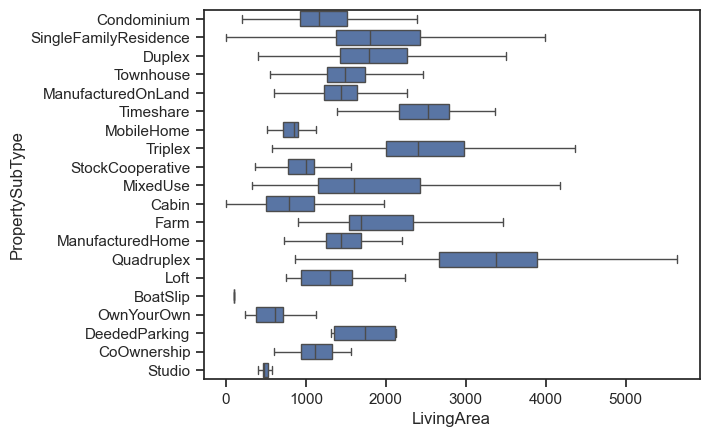

In [22]:
sns.boxplot(data=sold[sold["LivingArea"] < 100000], x="LivingArea", y="PropertySubType", showfliers=False)
plt.show()

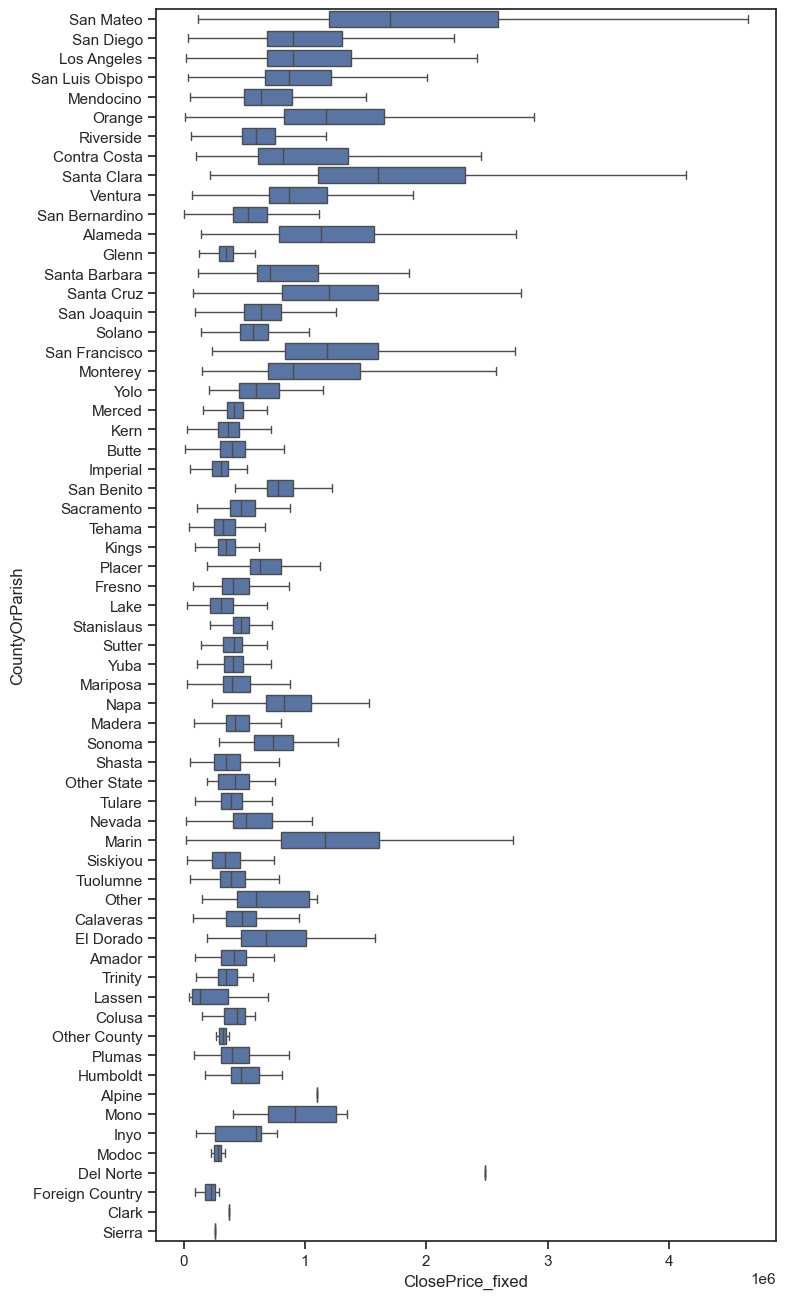

In [24]:
fig = plt.figure(figsize=(8,16))
sns.boxplot(data=sold, x="ClosePrice_fixed", y="CountyOrParish", showfliers=False)
plt.show()

In [50]:
sorted(sold["LivingArea"], reverse=True)

[17021321.0,
 123764.0,
 84500.0,
 56500.0,
 45322.0,
 33652.0,
 32644.0,
 32500.0,
 31068.0,
 30500.0,
 28502.0,
 26627.0,
 24350.0,
 23727.0,
 22897.0,
 22659.0,
 21609.0,
 20422.0,
 20000.0,
 20000.0,
 20000.0,
 19929.0,
 19474.0,
 18336.0,
 17398.0,
 17153.0,
 17005.0,
 16702.0,
 16683.0,
 16499.0,
 16489.0,
 16489.0,
 16450.0,
 16390.0,
 16225.0,
 16080.0,
 15803.0,
 15788.0,
 15776.0,
 15649.0,
 15578.0,
 15425.0,
 15404.0,
 15355.0,
 15305.0,
 15292.0,
 15251.0,
 15219.0,
 15100.0,
 15037.0,
 15024.0,
 15015.0,
 15006.0,
 15000.0,
 15000.0,
 15000.0,
 15000.0,
 14997.0,
 14779.0,
 14740.0,
 14715.0,
 14700.0,
 14605.0,
 14543.0,
 14452.0,
 14429.0,
 14168.0,
 14165.0,
 14164.0,
 14129.0,
 14093.0,
 14090.0,
 14085.0,
 14054.0,
 14042.0,
 14000.0,
 13962.0,
 13900.0,
 13787.0,
 13777.0,
 13737.0,
 13706.0,
 13631.0,
 13626.0,
 13525.0,
 13500.0,
 13500.0,
 13500.0,
 13500.0,
 13437.0,
 13404.0,
 13377.0,
 13300.0,
 13250.0,
 13206.0,
 13189.0,
 13126.0,
 13122.0,
 13108.0,
 13014

In [25]:
sold.groupby("PropertySubType")["PriceRatio_fixed"].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
PropertySubType,,,,,,,,,,,,
BoatSlip,45.0,0.949640,0.068600,0.648968,0.723122,0.883423,0.928571,0.967312,1.000000,1.000000,1.045565,1.047692
Cabin,470.0,0.937602,0.100678,0.480000,0.576454,0.806961,0.901203,0.963961,1.000000,1.012972,1.138474,1.455556
CoOwnership,17.0,0.964626,0.041166,0.875000,0.877222,0.916211,0.941176,0.974290,1.000000,1.006486,1.018540,1.019048
Condominium,68269.0,0.993534,0.045861,0.342857,0.875000,0.950000,0.974757,1.000000,1.006369,1.034091,1.130731,2.461385
DeededParking,4.0,1.010123,0.042583,0.960000,0.961200,0.972000,0.990000,1.008885,1.029008,1.049236,1.061373,1.062721
Duplex,2250.0,0.991256,0.082087,0.403614,0.801845,0.918350,0.960012,0.997373,1.010924,1.052632,1.252194,2.185273
Farm,14.0,0.979618,0.098171,0.818926,0.822734,0.861023,0.919082,0.978610,1.015526,1.119714,1.137148,1.138952
Loft,28.0,0.994644,0.048402,0.876190,0.879680,0.959962,0.975254,1.000000,1.003906,1.036245,1.117920,1.132265
ManufacturedHome,40.0,0.972673,0.051433,0.846667,0.859562,0.909855,0.936113,0.984649,1.000000,1.017405,1.093434,1.116883


In [34]:
sold.groupby("PropertySubType")["LivingArea"].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
PropertySubType,,,,,,,,,,,,
BoatSlip,45.0,120.000000,66.057826,100.0,100.00,100.00,100.00,100.0,100.00,160.0,400.00,400.0
Cabin,470.0,887.208511,530.976253,2.0,192.00,400.00,500.00,788.0,1103.00,1500.0,2965.58,3500.0
CoOwnership,17.0,1267.929412,662.301695,600.0,608.00,691.28,940.00,1118.0,1325.00,1854.2,3124.76,3283.0
Condominium,68269.0,1262.118663,587.722082,1.0,495.68,731.00,922.00,1168.0,1509.00,1885.0,2810.32,84500.0
DeededParking,4.0,1729.500000,454.335045,1310.0,1311.59,1325.90,1349.75,1740.0,2119.75,2124.7,2127.67,2128.0
Duplex,2250.0,1912.538222,764.543797,100.0,815.49,1100.00,1431.25,1785.0,2261.75,2778.3,4483.81,8474.0
Farm,14.0,2003.714286,879.714327,900.0,900.00,1050.00,1541.75,1683.0,2339.50,3388.1,3622.25,3645.0
Loft,28.0,1347.535714,512.081770,750.0,752.16,847.00,934.00,1305.5,1581.75,1951.1,2775.44,2972.0
ManufacturedHome,40.0,1524.725000,452.985650,728.0,849.68,1137.60,1257.00,1440.0,1692.50,1895.5,2808.08,2819.0


In [21]:
sorted(sold.loc[(sold["PropertySubType"] == "MixedUse") & (sold["LivingArea"] > 2432.5), "LivingArea"], reverse=True)

[28502.0,
 13500.0,
 10000.0,
 9378.0,
 8276.0,
 6169.0,
 6057.0,
 5879.0,
 5403.0,
 5000.0,
 5000.0,
 4991.0,
 4917.0,
 4550.0,
 4500.0,
 4174.0,
 3972.0,
 3847.0,
 3820.0,
 3637.0,
 3600.0,
 3596.0,
 3504.0,
 3500.0,
 3500.0,
 3480.0,
 3480.0,
 3469.0,
 3460.0,
 3385.0,
 3360.0,
 3324.0,
 3319.0,
 3075.0,
 3066.0,
 2934.0,
 2883.0,
 2852.0,
 2812.0,
 2786.0,
 2768.0,
 2750.0,
 2686.0,
 2673.0,
 2614.0,
 2600.0,
 2582.0,
 2539.0,
 2482.0,
 2448.0,
 2434.0]

In [49]:
(sold[["LivingArea", "PricePerSqft"]]).describe(percentiles=[0.005, 0.1, 0.25, 0.5, 0.75, 0.9, 0.995])

,LivingArea,PricePerSqft
count,4.124340e+05,412434.000000
mean,1.904657e+03,606.667911
std,2.652058e+04,1787.326764
min,1.000000e+00,0.037077
0.5%,5.440000e+02,133.333333
10%,9.840000e+02,264.639640
25%,1.248000e+03,368.231047
50%,1.643000e+03,537.010160
75%,2.219000e+03,731.401439
90%,2.978000e+03,988.078698


In [27]:
sold["PricePerSqft"] = sold["ClosePrice_fixed"] / sold["LivingArea"]
sold.PricePerSqft.describe(percentiles=[0.005, 0.1, 0.25, 0.5, 0.75, 0.9, 0.995])

count    412434.000000
mean        606.667911
std        1787.326764
min           0.037077
0.5%        133.333333
10%         264.639640
25%         368.231047
50%         537.010160
75%         731.401439
90%         988.078698
99.5%      2184.158853
max      735000.000000
Name: PricePerSqft, dtype: float64

In [61]:
sold.groupby("PropertySubType")["PricePerSqft"].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
PropertySubType,,,,,,,,,,,,
BoatSlip,45.0,2032.900000,919.939410,625.000000,658.000000,1145.600000,1499.000000,1750.000000,2500.000000,3351.000000,4412.000000,4500.000000
Cabin,470.0,614.940101,6538.216193,28.000000,51.996381,117.126053,189.496528,287.758241,389.230419,508.934322,1167.508721,142000.000000
CoOwnership,17.0,496.566215,307.770112,261.780105,268.076420,320.452830,342.729020,419.047619,480.000000,631.048799,1470.121706,1599.147122
Condominium,68269.0,608.057501,1408.280257,4.814793,209.918603,342.490596,442.852081,564.905660,702.462656,872.159770,1604.294458,362000.000000
DeededParking,4.0,410.512905,206.793056,240.906944,242.561314,257.450650,282.266210,348.407995,476.654691,613.259088,695.221727,704.328687
Duplex,2250.0,640.608610,447.129492,30.882353,132.912839,271.613899,403.702126,545.035789,725.989057,1077.190629,2433.965054,6187.500000
Farm,14.0,912.218587,513.531363,345.636534,353.153353,412.872362,542.004076,785.092620,1041.469547,1776.539039,1784.682540,1785.714286
Loft,28.0,549.938130,152.064825,346.054334,349.282285,403.660990,450.259173,515.078915,637.573304,720.067445,928.163025,928.571429
ManufacturedHome,40.0,199.842090,85.332522,83.473862,84.719056,133.402778,143.608345,183.121123,223.665450,308.698578,485.040404,502.525253


In [76]:
sold[sold["PricePerSqft"] > 8000][["ClosePrice", "ClosePrice_fixed", "LivingArea", "PricePerSqft", "PropertySubType"]].sort_values(by="PricePerSqft")

,ClosePrice,ClosePrice_fixed,LivingArea,PricePerSqft,PropertySubType
196611,10280000.0,10280000.0,1256.0,8184.713376,SingleFamilyResidence
300407,18625000.0,18625000.0,2258.0,8248.449956,SingleFamilyResidence
386157,16900000.0,16900000.0,2030.0,8325.123153,SingleFamilyResidence
331198,49999999.0,49999999.0,6003.0,8329.168582,SingleFamilyResidence
109945,35000000.0,35000000.0,3304.0,10593.220339,SingleFamilyResidence
279801,12750000.0,12750000.0,1068.0,11938.202247,SingleFamilyResidence
185559,7250000.0,7250000.0,600.0,12083.333333,SingleFamilyResidence
183567,1600000.0,1600000.0,100.0,16000.000000,Triplex
251862,1640000.0,1640000.0,100.0,16400.000000,SingleFamilyResidence
284476,22000000.0,22000000.0,1200.0,18333.333333,SingleFamilyResidence


In [80]:
sold[sold["LivingArea"] > 10000][["ClosePrice", "ClosePrice_fixed", "LivingArea", "PricePerSqft", "PropertySubType"]].sort_values(by="LivingArea")

,ClosePrice,ClosePrice_fixed,LivingArea,PricePerSqft,PropertySubType
156833,10300000.0,10300000.0,10009.0,1029.073834,SingleFamilyResidence
10352,22000000.0,22000000.0,10011.0,2197.582659,SingleFamilyResidence
237906,7700000.0,7700000.0,10019.0,768.539774,SingleFamilyResidence
340605,4000000.0,4000000.0,10038.0,398.485754,SingleFamilyResidence
126435,4000000.0,4000000.0,10038.0,398.485754,SingleFamilyResidence
...,...,...,...,...,...
133229,299995.0,299995.0,45322.0,6.619192,StockCooperative
285228,110000000.0,110000000.0,56500.0,1946.902655,SingleFamilyResidence
250905,406850.0,406850.0,84500.0,4.814793,Condominium
105755,16700000.0,16700000.0,123764.0,134.934230,SingleFamilyResidence


In [95]:
sold = sold[sold["LivingArea"].between(100, 10000)]

sold[sold["PricePerSqft"] < 10000].groupby("PropertySubType")["PricePerSqft"].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
PropertySubType,,,,,,,,,,,,
BoatSlip,45.0,2032.900000,919.939410,625.000000,658.000000,1145.600000,1499.000000,1750.000000,2500.000000,3351.000000,4412.000000,4500.000000
Cabin,469.0,313.479419,188.232281,28.000000,51.967448,117.064607,189.236111,287.581699,388.888889,499.557520,1131.922712,1366.723260
CoOwnership,17.0,496.566215,307.770112,261.780105,268.076420,320.452830,342.729020,419.047619,480.000000,631.048799,1470.121706,1599.147122
Condominium,68266.0,602.764064,264.781123,27.000000,209.993490,342.501585,442.853347,564.904753,702.429403,872.103350,1604.044983,4782.342121
DeededParking,4.0,410.512905,206.793056,240.906944,242.561314,257.450650,282.266210,348.407995,476.654691,613.259088,695.221727,704.328687
Duplex,2250.0,640.608610,447.129492,30.882353,132.912839,271.613899,403.702126,545.035789,725.989057,1077.190629,2433.965054,6187.500000
Farm,14.0,912.218587,513.531363,345.636534,353.153353,412.872362,542.004076,785.092620,1041.469547,1776.539039,1784.682540,1785.714286
Loft,28.0,549.938130,152.064825,346.054334,349.282285,403.660990,450.259173,515.078915,637.573304,720.067445,928.163025,928.571429
ManufacturedHome,40.0,199.842090,85.332522,83.473862,84.719056,133.402778,143.608345,183.121123,223.665450,308.698578,485.040404,502.525253


In [84]:
sold.PricePerSqft.describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count    412101.000000
mean        600.619335
std         364.830635
min           1.736111
1%          162.087912
10%         264.612954
25%         368.158706
50%         536.828964
75%         730.994152
90%         987.095314
99%        1863.234729
max       60000.000000
Name: PricePerSqft, dtype: float64

In [92]:
sold[sold["PricePerSqft"] > 10000][["ClosePrice", "ClosePrice_fixed", "LivingArea", "PricePerSqft", "PropertySubType"]].sort_values(by="PricePerSqft")

,ClosePrice,ClosePrice_fixed,LivingArea,PricePerSqft,PropertySubType
109945,35000000.0,35000000.0,3304.0,10593.220339,SingleFamilyResidence
279801,12750000.0,12750000.0,1068.0,11938.202247,SingleFamilyResidence
185559,7250000.0,7250000.0,600.0,12083.333333,SingleFamilyResidence
183567,1600000.0,1600000.0,100.0,16000.000000,Triplex
251862,1640000.0,1640000.0,100.0,16400.000000,SingleFamilyResidence
284476,22000000.0,22000000.0,1200.0,18333.333333,SingleFamilyResidence
77861,1862935.0,1862935.0,100.0,18629.350000,SingleFamilyResidence
185562,6000000.0,6000000.0,100.0,60000.000000,SingleFamilyResidence


In [97]:
sold["DaysOnMarket"]
sold["DaysOnMarket"].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count    412101.000000
mean         37.321644
std          53.318542
min        -288.000000
1%            0.000000
10%           4.000000
25%           8.000000
50%          18.000000
75%          48.000000
90%          94.000000
99%         230.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

In [114]:
sold[sold["DaysOnMarket"] > 500][key_metrics]

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,PriceRatio,PricePerSqft,DaysOnMarket,CloseYrMo,ListContractDays,ContractCloseDays
0,240000.0,295000.0,499000.0,1140.0,0.813559,210.526316,777,2024-01,16.0,4.0
11153,625000.0,669000.0,869000.0,800.0,0.934230,781.250000,566,2024-01,5.0,1.0
11158,1097191.0,1096379.0,997500.0,2433.0,1.000741,450.962187,537,2024-01,21.0,-2.0
11159,1825000.0,1995000.0,2395000.0,2835.0,0.914787,643.738977,539,2024-01,21.0,1.0
11163,1034390.0,999990.0,1024990.0,2903.0,1.034400,356.317602,530,2024-01,12.0,5.0
...,...,...,...,...,...,...,...,...,...,...
412428,405000.0,420000.0,459000.0,2176.0,0.964286,186.121324,660,2026-04,-1.0,-24.0
412429,215000.0,215000.0,279000.0,1508.0,1.000000,142.572944,680,2026-04,10.0,-27.0
412430,415000.0,419000.0,449000.0,1583.0,0.990453,262.160455,702,2026-04,4.0,1.0
412431,1355000.0,1399999.0,1579000.0,2268.0,0.967858,597.442681,695,2026-04,-7.0,13.0
